Số lượng hành khách trong tập train: 891


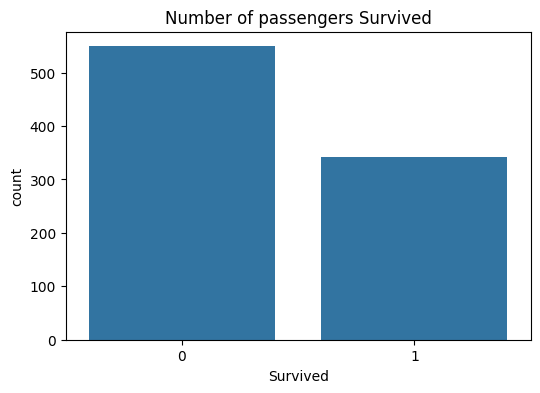

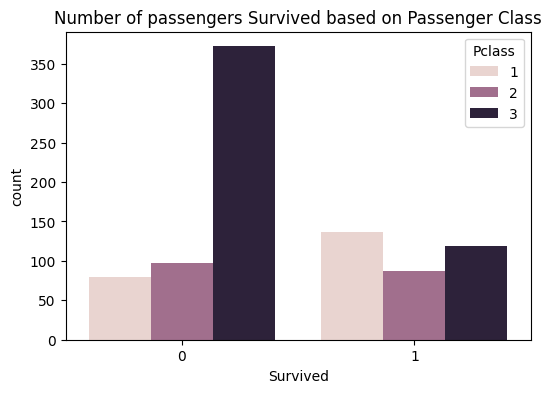

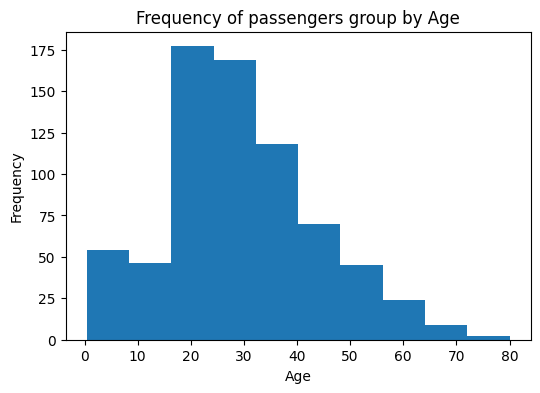

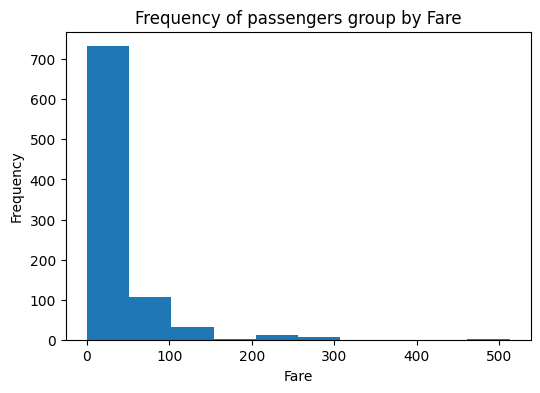


--- Train Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


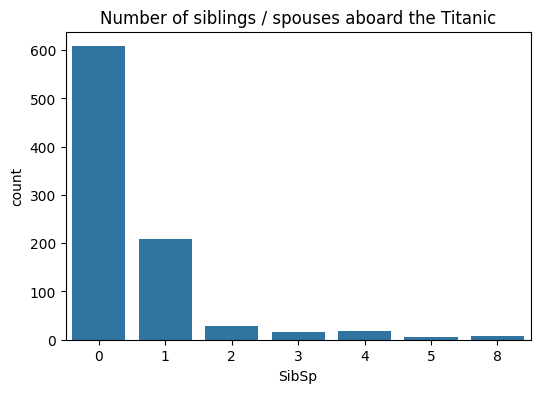


Số lượng giá trị NULL trong tập train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


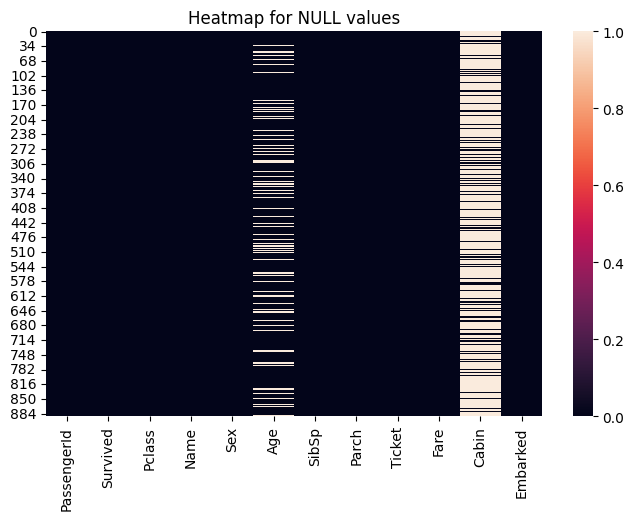

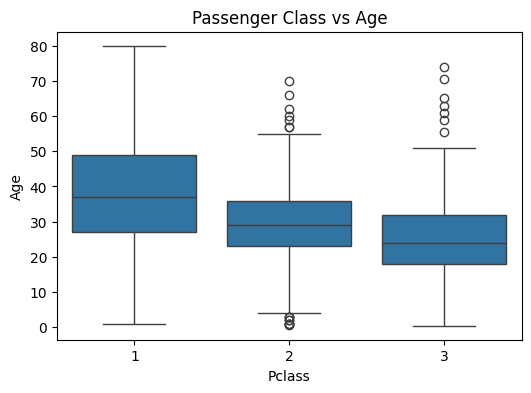


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       153
           1       0.81      0.65      0.72       115

    accuracy                           0.78       268
   macro avg       0.79      0.77      0.77       268
weighted avg       0.79      0.78      0.78       268

--- CONFUSION MATRIX ---
[[135  18]
 [ 40  75]]
--- ACCURACY SCORE ---
0.7835820895522388

Đã tạo thành công file submission.csv!


In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Tải dữ liệu từ Kaggle
input_base = '../input'
if not os.path.exists(input_base):
    input_base = '/kaggle/input'

data_dir = None
for root, dirs, files in os.walk(input_base):
    if 'train.csv' in files:
        data_dir = root
        break

train_path = os.path.join(data_dir, 'train.csv')
test_path = os.path.join(data_dir, 'test.csv')

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
test_passenger_id = test['PassengerId']

print(f"Số lượng hành khách trong tập train: {len(train)}")

# ==========================================
# 2. DATA ANALYSIS (TRỰC QUAN HÓA BẰNG BIỂU ĐỒ)
# ==========================================

# Biểu đồ 1: Số người sống sót
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=train)
plt.title("Number of passengers Survived")
plt.show()

# Biểu đồ 2: Số người sống sót theo Hạng vé (Pclass)
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', hue='Pclass', data=train)
plt.title("Number of passengers Survived based on Passenger Class")
plt.show()

# Biểu đồ 3: Phân bố Độ tuổi (Age)
plt.figure(figsize=(6, 4))
train['Age'].plot.hist()
plt.title("Frequency of passengers group by Age")
plt.xlabel("Age")
plt.show()

# Biểu đồ 4: Phân bố Giá vé (Fare)
plt.figure(figsize=(6, 4))
train['Fare'].plot.hist()
plt.title("Frequency of passengers group by Fare")
plt.xlabel("Fare")
plt.show()

# Thông tin dữ liệu tập train
print("\n--- Train Dataset Information ---")
train.info()

# Biểu đồ 5: Số anh chị em/vợ chồng (SibSp)
plt.figure(figsize=(6, 4))
sns.countplot(x='SibSp', data=train)
plt.title("Number of siblings / spouses aboard the Titanic")
plt.show()

# Kiểm tra dữ liệu khuyết
print("\nSố lượng giá trị NULL trong tập train:")
print(train.isnull().sum())

# Biểu đồ 6: Heatmap kiểm tra vị trí giá trị NULL
plt.figure(figsize=(8, 5))
sns.heatmap(train.isnull())
plt.title("Heatmap for NULL values")
plt.show()

# Biểu đồ 7: Boxplot Pclass vs Age
plt.figure(figsize=(6, 4))
sns.boxplot(x='Pclass', y='Age', data=train)
plt.title("Passenger Class vs Age")
plt.show()

# ==========================================
# 3. DATA PREPROCESSING (TIỀN XỬ LÝ DỮ LIỆU)
# ==========================================

sex_train = pd.get_dummies(train['Sex'], drop_first=True, dtype=int)
embark_train = pd.get_dummies(train['Embarked'], drop_first=True, dtype=int)
pcl_train = pd.get_dummies(train['Pclass'], prefix='Pclass', drop_first=True, dtype=int)

train = pd.concat([train, sex_train, embark_train, pcl_train], axis=1)
train.drop(['Pclass', 'Sex', 'Embarked', 'Cabin', 'PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
train['Age'] = train['Age'].fillna(round(train['Age'].mean()))

# Tiền xử lý tập Test
sex_test = pd.get_dummies(test['Sex'], drop_first=True, dtype=int)
embark_test = pd.get_dummies(test['Embarked'], drop_first=True, dtype=int)
pcl_test = pd.get_dummies(test['Pclass'], prefix='Pclass', drop_first=True, dtype=int)

test = pd.concat([test, sex_test, embark_test, pcl_test], axis=1)
test.drop(['Pclass', 'Sex', 'Embarked', 'Cabin', 'PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
test['Age'] = test['Age'].fillna(round(test['Age'].mean()))
test['Fare'] = test['Fare'].fillna(round(test['Fare'].mean()))

# ==========================================
# 4. HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH
# ==========================================

X = train.drop('Survived', axis=1)
y = train['Survived']

X.columns = X.columns.astype(str)
test.columns = test.columns.astype(str)
test = test[X.columns]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

logmodel = LogisticRegression(solver='liblinear')
logmodel.fit(X_train, y_train)

predictions = logmodel.predict(X_test)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, predictions))

print("--- CONFUSION MATRIX ---")
print(confusion_matrix(y_test, predictions))

print("--- ACCURACY SCORE ---")
print(accuracy_score(y_test, predictions))

# ==========================================
# 5. DỰ ĐOÁN TẬP TEST VÀ TẠO FILE SUBMISSION
# ==========================================

test_predictions = logmodel.predict(test)
submission = pd.DataFrame({
    'PassengerId': test_passenger_id,
    'Survived': test_predictions
})
submission.to_csv('submission.csv', index=False)
print("\nĐã tạo thành công file submission.csv!")